---
# Timescales - Heterogeneous RNN 
---

## Imports

In [ ]:
# Standard library
import os, re, glob, time, gc, copy, tempfile, uuid, pickle, json, socket, sys
from tqdm import tqdm

# Core scientific stack
import numpy as np
import numba as nb
import pandas as pd
import torch
import math
from math import gamma
from scipy.stats import gamma as gamma_dist
import scipy.signal as signal
from statsmodels.tsa.stattools import acf
from scipy.special import gammaln

# Parallelization
from joblib import Parallel, delayed

# Plotting
import matplotlib as mpl
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Scientific / ML
from scipy.integrate import solve_ivp, simpson
from scipy.signal import correlate
from numpy.polynomial.hermite import hermgauss
from numpy.linalg import eigh
from sklearn.linear_model import Ridge, LinearRegression
from scipy.signal import welch, get_window
from scipy.optimize import root_scalar, fsolve
from scipy.interpolate import griddata

## Plotting Utils

In [28]:
def plot_dynamics(x, t=None, dt=0.1, n_plot=10, N=None, title=None, cmap='Blues', label=None):
    '''
    Plot dynamics of the RNN (subset of neuron trajectories over time)
    '''
    time_steps = x.shape[1]
    N = x.shape[0]

    # Build time axis if not provided
    if t is None: 
        t = np.arange(0, int(time_steps * dt), dt)

    # Select random neuron indices to display
    random_indices = np.random.choice(N, size=n_plot, replace=False)
    selected_trajectories = x[random_indices, :]

    # Choose colors from a seaborn palette
    colors = sns.color_palette(cmap, n_plot)

    # Plot trajectories
    for i in range(n_plot):
        plt.plot(t, selected_trajectories[i, :], lw=1.5, color=colors[i], label=label if i == 0 else None)

    # Optional title
    if title:
        plt.title(title)
    
    plt.xlabel('Time (ms)')
    plt.ylabel('x(t)')

    # Set y-limits based on plotted traces
    ymin = np.round(np.min(selected_trajectories), 1)
    ymax = np.round(np.max(selected_trajectories), 1)
    plt.ylim(ymin, ymax)


def plot_acf(C, time_lags, label=None, color='C0'):
    '''
    Plot the mean autocorrelation function (ACF) with standard deviation
    '''
    C = C.T
    mean_acf = np.mean(C, axis=1)
    sig_acf = np.sqrt(np.var(C, axis=1))
    
    plt.plot(time_lags, mean_acf, lw=1.5, label=label, color=color, zorder=0)
    plt.fill_between(time_lags, mean_acf - sig_acf, mean_acf + sig_acf, color=color, alpha=0.3, label='std')
    
    plt.title('ACF', fontsize=15)
    plt.xlabel(r'$\tau$', fontsize=13)
    plt.ylabel(r'C($\tau$)', fontsize=13)
    plt.legend(frameon=False, fontsize=12)

    # Clean axis spines
    ax = plt.gca()
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)


def plot_theoretical_degree_distribution(model, bins=100, k_grid_size=2000, k_max_plot=None):
    '''
    Plot the theoretical degree distribution associated with the chosen model distribution
    '''
    dist = model.distribution
    N = int(model.N)

    # Poisson degree distribution
    if dist == "poisson":
        lam = float(model.K)
        kmax = int(np.ceil(lam + 8*np.sqrt(max(lam, 1e-9)))) if k_max_plot is None else int(k_max_plot)
        k = np.arange(0, kmax + 1, dtype=np.int64)
        logpmf = -lam + k*np.log(max(lam, 1e-300)) - gammaln(k + 1.0)
        pmf = np.exp(logpmf)
        pmf = pmf / pmf.sum()

        plt.plot(k, pmf, lw=2)
        return k, pmf

    # Log-normal degree distribution (continuous approximation)
    if dist == "log_normal":
        mu = float(model.mu_ln)
        sig = float(model.sig_ln)
        if k_max_plot is None:
            k_hi = float(np.exp(mu + 4*sig))
        else:
            k_hi = float(k_max_plot)
        k_lo = max(1e-6, float(np.exp(mu - 4*sig)))
        k = np.logspace(np.log10(k_lo), np.log10(k_hi), k_grid_size)

        pdf = (1.0/(k*sig*np.sqrt(2*np.pi))) * np.exp(-(np.log(k)-mu)**2/(2*sig**2))
        area = np.trapz(pdf, k)
        if area > 0:
            pdf = pdf / area
        plt.plot(k, pdf, lw=2)
        return k, pdf

    # Power-law degree distribution
    if dist == "power_law":
        alpha = float(model.alpha)
        k_min = float(model.k_min)
        k_max = float(model.k_max if k_max_plot is None else k_max_plot)

        k = np.logspace(np.log10(k_min), np.log10(k_max), k_grid_size)
        C = (1.0 - alpha) / (k_max**(1.0 - alpha) - k_min**(1.0 - alpha))
        pdf = C * k**(-alpha)

        area = np.trapz(pdf, k)
        if area > 0:
            pdf = pdf / area
        
        plt.plot(k, pdf, lw=2)
        return k, pdf

    # Fully connected case (all nodes have degree N)
    if dist == "full":
        k = np.array([N], dtype=np.int64)
        pmf = np.array([1.0], dtype=np.float64)

        plt.stem(k, pmf, use_line_collection=True) # type: ignore
        return k, pmf

    raise ValueError(f"Unsupported distribution type: {dist}")

## RNN model


In [27]:
# Mapping between activation names and integer codes used internally
ACT_MAP2 = {"tanh": 0, "linear": 1, "logistic": 2}

# Apply activation function based on the selected code
@torch.no_grad()
def _phi_torch2(x: torch.Tensor, act_code: int):
    if act_code == 0:
        return torch.tanh(x)
    if act_code == 1:
        return x
    return torch.sigmoid(x)

# Convert input to torch float64 tensor on CPU
@torch.no_grad()
def _ensure_torch64_cpu(a, shape=None):
    if a is None:
        return None
    if isinstance(a, np.ndarray):
        t = torch.from_numpy(a).to(dtype=torch.float64, device="cpu")
    else:
        t = torch.as_tensor(a, dtype=torch.float64, device="cpu")
    if shape is not None and tuple(t.shape) != tuple(shape):
        raise ValueError(f"array must have shape {shape}, got {tuple(t.shape)}")
    return t

# Simulate RNN dynamics using streaming integration
# Activity is computed in chunks to reduce GPU memory usage
@torch.no_grad()
def _simulate_rnn_degree_streaming(
    act_code, W, steps, dt, tau_x, k_x, x0,
    chunk_steps: int = 100000,
    out_target: str = "cpu",
    out_memmap_path: str | None = None,
    out_dtype=np.float64
):
    device = W.device
    N = W.shape[0]

    # Allocate output array either in RAM or as disk memmap
    if out_target == "cpu" and out_memmap_path is None:
        out_host = np.empty((steps, N), dtype=out_dtype)
    else:
        if out_memmap_path is None:
            raise ValueError("Specify out_memmap_path for memmap on disk.")
        out_host = np.memmap(
            out_memmap_path, mode="w+", dtype=out_dtype, shape=(steps, N)
        )

    # Initial state
    cur = torch.as_tensor(x0, dtype=torch.float64, device=device)
    out_host[0, :] = cur.detach().cpu().numpy()

    inv_tau = 1.0 / float(tau_x)
    kk = float(k_x)
    dtv = float(dt)

    t_global = 1
    while t_global < steps:
        t_end = min(t_global + chunk_steps, steps)
        blk_len = t_end - t_global

        block_gpu = torch.empty((blk_len, N), dtype=torch.float64, device=device)
        for k in range(blk_len):
            drift = inv_tau * (-kk * cur + W @ _phi_torch2(cur, act_code))
            cur = cur + drift * dtv
            block_gpu[k] = cur

        # Move block back to CPU
        block_cpu = block_gpu.to("cpu", non_blocking=True)
        if device.type == "cuda":
            torch.cuda.synchronize(device)
        out_host[t_global:t_end, :] = block_cpu.numpy()
        t_global = t_end

    return out_host

# Recurrent neural network model
class RNN_model:
    # Initialize model parameters
    def __init__(
        self, mu=0, g=0.5, set_selfcoupling=False, s=0.0, gamma=0,
        N=100, T=500, dt=None, J=None, A=None,
        tau_x=1.0, k_x=1.0, tau_p=1.0, p=0, K=1,
        k_min=1, k_max=300, alpha=1, mu_ln=3, sig_ln=1,
        activation="tanh", distribution="poisson",
        device=None
    ):
        if device is None:
            self.device = torch.device(
                "cuda" if torch.cuda.is_available() else "cpu"
            )
        else:
            self.device = torch.device(device)

        self.set_parameters(
            mu=mu, g=g, set_selfcoupling=set_selfcoupling,
            s=s, gamma=gamma, N=N, T=T, dt=dt,
            J=J, A=A, tau_x=tau_x, k_x=k_x,
            tau_p=tau_p, p=p, K=K,
            k_min=k_min, k_max=k_max, alpha=alpha,
            mu_ln=mu_ln, sig_ln=sig_ln,
            activation=activation, distribution=distribution
        )

    # Update parameters and construct connectivity matrices
    def set_parameters(
        self, mu=None, g=None, set_selfcoupling=None, s=None, gamma=None,
        N=None, T=None, dt=None, J=None, A=None,
        tau_x=None, k_x=None, tau_p=None, p=None, K=None,
        k_min=None, k_max=None, alpha=None,
        mu_ln=None, sig_ln=None,
        activation=None, distribution=None
    ):
        if mu is not None: self.mu = float(mu)
        if g is not None: self.g = float(g)
        if set_selfcoupling is not None: self.set_selfcoupling = bool(set_selfcoupling)
        if s is not None: self.s = float(s)
        if gamma is not None: self.gamma = float(gamma)
        if N is not None: self.N = int(N)
        if T is not None: self.T = float(T)
        if dt is not None: self.dt = float(dt)
        if tau_x is not None: self.tau_x = float(tau_x)
        if k_x is not None: self.k_x = float(k_x)
        if tau_p is not None: self.tau_p = float(tau_p)
        if p is not None: self.p = float(p)
        if activation is not None: self.activation = str(activation)
        if distribution is not None: self.distribution = str(distribution)
        if k_min is not None: self.k_min = float(k_min)
        if k_max is not None: self.k_max = float(k_max)
        if alpha is not None: self.alpha = float(alpha)
        if mu_ln is not None: self.mu_ln = float(mu_ln)
        if sig_ln is not None: self.sig_ln = float(sig_ln)

        # Compute expected degree depending on distribution
        if K is not None:
            if self.distribution == "poisson":
                self.K = float(K)
            elif self.distribution == "power_law":
                _, mean, _ = self.g_critical_power_law()
                self.K = float(mean)
            elif self.distribution == "log_normal":
                self.K = float(np.exp(self.mu_ln + (self.sig_ln ** 2) / 2))
            elif self.distribution == "full":
                self.K = float(self.N)
            else:
                raise ValueError("Unsupported distribution type")

        # Sample adjacency matrix
        self.A = self.sample_adjacency_matrix() if A is None else self._ensure_bin_adj(A)
        self.K_eff = float(torch.sum(self.A, dim=1).double().mean().item())

        # Sample interaction matrix
        if J is None:
            if self.gamma == 0:
                self.J = torch.randn(
                    (self.N, self.N), dtype=torch.float64, device=self.device
                ) * (self.g / (self.K_eff ** 0.5))
            else:
                self.J = self.sample_interaction_matrix()
        else:
            self.J = self._ensure_torch64(J)

        self.W = self.J * self.A
        if self.set_selfcoupling:
            idx = torch.arange(self.N, device=self.device)
            self.W[idx, idx] = float(self.s)

        if not hasattr(self, "dt") or self.dt is None:
            raise ValueError("dt must be provided for GPU simulation.")
        self.steps = int(self.T / self.dt)

    # Convert input to torch float64 tensor on the model device
    def _ensure_torch64(self, x):
        if isinstance(x, np.ndarray):
            return torch.from_numpy(x).to(dtype=torch.float64, device=self.device)
        return torch.as_tensor(x, dtype=torch.float64, device=self.device)

    # Ensure adjacency matrix is binary, symmetric, and has the correct shape
    def _ensure_bin_adj(self, A):
        t = self._ensure_torch64(A)
        if t.shape != (self.N, self.N):
            raise ValueError(f"A must have shape ({self.N}, {self.N})")
        t = (t != 0).to(dtype=torch.float64)
        t = torch.triu(t, diagonal=1)
        t = t + t.T
        return t

    # Critical coupling for the power-law degree distribution
    def g_critical_power_law(self):
        kmin = float(self.k_min)
        kmax = float(self.k_max)
        a = float(self.alpha)
        norm = (1 - a) / (kmax ** (1 - a) - kmin ** (1 - a))
        mean = norm * (kmax ** (2 - a) - kmin ** (2 - a)) / (2 - a)
        second_moment = norm * (kmax ** (3 - a) - kmin ** (3 - a)) / (3 - a)
        g_crit = (mean ** 2 / second_moment) ** 0.5
        return g_crit, mean, second_moment

    # Sample degrees according to the chosen distribution
    def generate_degree_sequence(self):
        N = self.N
        dev = self.device
        if self.distribution == "poisson":
            k = torch.poisson(torch.full((N,), float(self.K), dtype=torch.float64, device=dev))
        elif self.distribution == "power_law":
            u = torch.rand((N,), dtype=torch.float64, device=dev)
            kmin = float(self.k_min)
            kmax = float(self.k_max)
            a = float(self.alpha)
            k = (kmin ** (1 - a) + u * (kmax ** (1 - a) - kmin ** (1 - a))) ** (1 / (1 - a))
        elif self.distribution == "log_normal":
            d = torch.distributions.LogNormal(
                loc=torch.tensor(float(self.mu_ln), dtype=torch.float64, device=dev),
                scale=torch.tensor(float(self.sig_ln), dtype=torch.float64, device=dev)
            )
            k = d.sample((N,))
        elif self.distribution == "full":
            k = torch.ones((N,), dtype=torch.float64, device=dev) * float(N)
        else:
            raise ValueError("Unsupported distribution type")
        return k

    # Connection probabilities from degree sequence
    def evaluate_p(self, k):
        return torch.outer(k, k) / (float(self.N) * float(self.K))

    # Sample adjacency matrix using probabilities p_ij
    def sample_adjacency_matrix(self):
        k = self.generate_degree_sequence()
        p = self.evaluate_p(k)
        p = torch.clamp(p, 0.0, 1.0)
        U = torch.rand((self.N, self.N), dtype=torch.float64, device=self.device)
        A = (U < p).to(dtype=torch.float64)
        A = torch.triu(A, diagonal=1)
        A = A + A.T
        return A

    # Sample interaction matrix with correlation controlled by gamma
    def sample_interaction_matrix(self):
        z1 = torch.randn((self.N, self.N), dtype=torch.float64, device=self.device)
        z2 = torch.randn((self.N, self.N), dtype=torch.float64, device=self.device)

        upper = (self.mu / self.N) + (self.g / (self.K_eff ** 0.5)) * z1
        lower = (self.mu / self.N) + (self.g / (self.K_eff ** 0.5)) * (
            self.gamma * z1 + (1 - self.gamma ** 2) ** 0.5 * z2
        )

        mat = torch.zeros((self.N, self.N), dtype=torch.float64, device=self.device)
        triu = torch.triu_indices(self.N, self.N, offset=1, device=self.device)
        i, j = triu
        mat[i, j] = upper[i, j]
        mat[j, i] = lower[i, j]
        return mat

    # Simulate RNN activity and return activity and time vector
    @torch.no_grad()
    def simulate_RNN(
        self, x0=None, stream=True, chunk_steps=2000,
        out_target="cpu", out_memmap_path=None, out_dtype=np.float64
    ):
        if self.activation not in ACT_MAP2:
            raise ValueError(f"activation must be in {list(ACT_MAP2.keys())}")
        act_code = ACT_MAP2[self.activation]

        # Initial condition
        if x0 is None:
            x0_t = torch.randn((self.N,), dtype=torch.float64, device=self.device)
        else:
            x0_t = torch.as_tensor(x0, dtype=torch.float64, device=self.device)
            if x0_t.shape != (self.N,):
                raise ValueError(f"x0 must have shape ({self.N},)")

        # Streaming simulation (recommended for long runs)
        if stream:
            X_host = _simulate_rnn_degree_streaming(
                act_code=act_code, W=self.W,
                steps=self.steps, dt=self.dt,
                tau_x=self.tau_x, k_x=self.k_x,
                x0=x0_t,
                chunk_steps=chunk_steps,
                out_target=out_target,
                out_memmap_path=out_memmap_path,
                out_dtype=out_dtype
            )
        else:
            # Full simulation stored on device
            steps = self.steps
            N = self.N
            dtv = float(self.dt)
            inv_tau = 1.0 / float(self.tau_x)
            kk = float(self.k_x)

            act = torch.empty((steps, N), dtype=torch.float64, device=self.device)
            act[0] = x0_t
            for t in range(1, steps):
                cur = act[t - 1]
                drift = inv_tau * (-kk * cur + self.W @ _phi_torch2(cur, act_code))
                act[t] = cur + drift * dtv

            X_host = act.to("cpu").numpy()

        # Time vector
        t = (torch.arange(self.steps, dtype=torch.float64, device=self.device) * self.dt).cpu().numpy()
        return X_host.T, t

## Utils

In [29]:
# Equation used to solve for k_min in the power-law case (given target mean degree K)
def equation_kmin(k_min, alpha, K, k_max):
    if k_min >= k_max:
        return np.inf
    C = (1 - alpha) / (k_max**(1 - alpha) - k_min**(1 - alpha))
    integral_part = (k_max**(2 - alpha) - k_min**(2 - alpha)) / (2 - alpha)
    return C * integral_part - K


# Solve for k_min numerically so that the power-law distribution has mean degree K
def evaluate_kmin(K, k_max, alpha):
    k_min_0 = 1.0
    k_min_sol = fsolve(equation_kmin, k_min_0, args=(alpha, K, k_max))
    return float(k_min_sol[0])


# Build a model and (if needed) resample until K_eff matches K within tolerance
def find_valid_model_cuda(tol=1.0, max_attempts=None, strict=False, **model_kwargs):
    if "dt" not in model_kwargs or model_kwargs["dt"] is None:
        raise ValueError("dt must be provided (GPU simulator is discrete-time Euler).")

    N = int(model_kwargs.get("N", 1000))

    # Default number of attempts depends on network size
    if max_attempts is None:
        max_attempts = 40 if N < 1500 else 20 if N < 3500 else 10 if N < 5500 else 5
    max_attempts = max(1, int(max_attempts))

    dist = model_kwargs.get("distribution", "poisson")

    # Pre-compute distribution-specific parameters before building the model
    if dist == "power_law":
        model_kwargs["k_min"] = evaluate_kmin(model_kwargs["K"], model_kwargs["k_max"], model_kwargs["alpha"])
    elif dist == "log_normal":
        model_kwargs["K"] = float(np.exp(model_kwargs["mu_ln"] + model_kwargs["sig_ln"]**2 / 2))
    elif dist in ["full", "poisson"]:
        return RNN_model(**model_kwargs)
    else:
        raise ValueError("Unsupported distribution type")

    best_model = None
    best_err = float("inf")

    # Try multiple random draws and keep the one closest to the target
    for _ in range(max_attempts):
        model = RNN_model(**model_kwargs)
        err = abs(float(model.K) - float(model.K_eff))
        if err < best_err:
            best_err = err
            best_model = model
        if err <= tol:
            return model

    if best_model is None:
        raise RuntimeError("Internal error: no model was created.")

    # Optionally enforce strict tolerance
    if strict and best_err > tol:
        raise RuntimeError(f"Could not meet tol={tol}. Best error={best_err:.4g} after {max_attempts} attempts.")

    return best_model


# Compute half-width at half-maximum (HWHM) of an autocorrelation curve by linear interpolation
def compute_decay_time(acf_values):
    half_max = acf_values[0] / 2
    indices = np.where(acf_values < half_max)[0]

    if len(indices) == 0:
        return None

    i = indices[0]
    x0, x1 = i - 1, i
    y0, y1 = acf_values[x0], acf_values[x1]
    hwhm = x0 + (half_max - y0) * (x1 - x0) / (y1 - y0)

    return hwhm


# Compute ACF for each unit and extract HWHM values
def compute_acf_act(sim, T_start, dt, maxlags=None):
    sim = np.asarray(sim)
    N, T = sim.shape
    T0 = int(T_start / dt)

    # Default maximum lag is 100 time units
    if maxlags is None:
        maxlags = int(100 / dt)
    else:
        maxlags = int(maxlags / dt)

    # Remove mean after burn-in
    x = sim[:, T0:] - sim[:, T0:].mean(axis=1, keepdims=True)

    acf_list = []
    hwhm_list = []

    for i in range(N):
        a = acf(x[i], nlags=maxlags-1, fft=True, adjusted=True)
        if np.isnan(a).any():
            continue
        else:
            hwhm = compute_decay_time(a)
            hwhm_list.append(hwhm * dt if hwhm is not None else np.nan)
            acf_list.append(a)

    lags = np.arange(len(acf_list[0])) * dt
    return acf_list, hwhm_list, lags


# Coefficient of variation (std / mean)
def coefficient_of_variation(x):
    mean = np.mean(x)
    std = np.std(x)
    return std / mean


# Variance across units at the final time point
def variance_at_final_time(x):
    return np.var(x[:, -1])


# Mean of per-unit variances over the last 10 percent of the simulation
def variance_last_percent(x, T, dt):
    T_start = int((0.9 * T) / dt)
    return np.mean(np.var(x[:, T_start:], axis=1))


# Run one simulation and save summary statistics and HWHM distribution to disk
def simulate_and_save(model_kwargs, run_idx, output_dir, t_start=500, maxlags=500):
    '''
    Function to simulate the RNN and save the results
    '''
    model = find_valid_model_cuda(tol=0.1, max_attempts=20, **model_kwargs)

    # Run simulation (streaming mode to limit memory usage)
    x, _ = model.simulate_RNN(stream=True, chunk_steps=20000)
    x = x.astype(np.float32)

    # Compute summary statistics
    var_lp = variance_last_percent(x, model_kwargs['T'], model_kwargs['dt'])
    var_f = variance_at_final_time(x)
    _, HWHM, _ = compute_acf_act(x, T_start=t_start, dt=model_kwargs['dt'], maxlags=maxlags)

    # Free memory
    del x
    gc.collect()

    # Build output filename and save everything in a compressed npz
    filename_base = f"N{model.N}_run{run_idx}_dist{model.distribution}_gam{model.gamma}_sigln{model.sig_ln}"
    data_path = os.path.join(output_dir, filename_base + ".npz")

    params = {k: v for k, v in model_kwargs.items() if v is not None}

    np.savez_compressed(
        data_path,
        HWHM=HWHM,
        var_lp=var_lp,
        var_f=var_f,
        **params
    )

## Simulation (check)

In [32]:
base_kwargs = {
    "mu": 0,
    "g": 3.0,
    "set_selfcoupling": True,
    "s": 0.0,
    "gamma": 0.3,
    "N": 4000,
    "T": 5000,
    "dt": 0.05,
    "J": None,
    "A": None,            
    "tau_x": 1.0,
    "k_x": 1.0,
    "tau_p": 1.0,
    "p": 0,
    "K": 100,
    "k_min": 1,
    "k_max": 4000,
    "alpha": 1.5,
    "mu_ln": 3,
    "sig_ln": 1,
    "activation": "tanh",
    "distribution": "log_normal",
    "device": "cuda"        
}

In [33]:
model = find_valid_model_cuda(tol=0.1, max_attempts=20, **base_kwargs)
start = time.time()
x, t = model.simulate_RNN(stream=True, chunk_steps=20000)  # x is (N, steps)
end = time.time()
print('Time:', end-start)

Time: 20.048063039779663


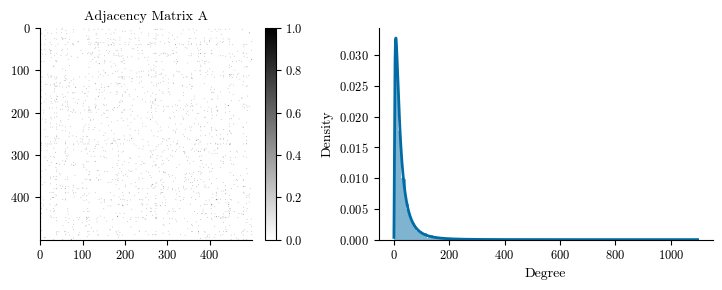

In [42]:
A_mat = model.A.cpu().numpy()
W_mat = model.W.cpu().numpy()
degree_vect = np.sum(A_mat, axis=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))

im = ax1.imshow(A_mat[:500, :500], cmap='binary')
ax1.set_title('Adjacency Matrix A')
cbar = fig.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)

ax2.hist(degree_vect, bins=100, density=True, color='C0', alpha=0.5)
plt.sca(ax2)
plot_theoretical_degree_distribution(model)
ax2.set_xlabel('Degree', fontsize=10)
ax2.set_ylabel('Density', fontsize=10)

plt.tight_layout()
plt.show()

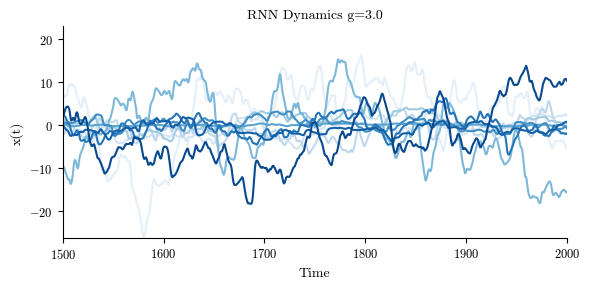

In [40]:
plt.figure(figsize=(6, 3))
plot_dynamics(x, t=t, dt=model.dt, n_plot=10, N=model.N, title=fr'RNN Dynamics g={model.g}', cmap='Blues')
plt.xlabel('Time')
plt.gca().locator_params(axis='both', nbins=5)
plt.xlim(1500, 2000)
plt.show()

# Loop

In [ ]:
OUT_PATH = "/data/taffarello/hetrnn/timescale_hetrnn/"

In [ ]:
# Run simualtions for Poisson degree distribution
gamma_list = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]

# Base model parameters
base_kwargs = {
    "mu": 0,
    "g": 3.0,
    "set_selfcoupling": True,
    "s": 0.0,
    "gamma": None,
    "N": 4000,
    "T": 4000,
    "dt": 0.05,
    "J": None,
    "A": None,
    "tau_x": 1.0,
    "k_x": 1.0,
    "tau_p": 1.0,
    "p": 0,
    "K": 100,
    "k_min": 1,
    "k_max": 4000,
    "alpha": None,
    "mu_ln": 3,
    "sig_ln": 1,
    "activation": "tanh",
    "distribution": "poisson",
    "device": "cuda"
}

# Output directory
output_dir = os.path.join(OUT_PATH, "sim_timescale_poiss")

# Simulation settings
total_sim = 20
T_START = 1000
MAX_LAGS = 600

# Loop over gamma values and runs
for gamma in gamma_list:
    for run_idx in range(total_sim):
        base_kwargs['gamma'] = gamma
        simulate_and_save(
            base_kwargs,
            run_idx,
            output_dir,
            t_start=T_START,
            maxlags=MAX_LAGS
        )

In [ ]:
# Run simulations for log-normal degree distribution
sigma_list = [0.01, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2]
gamma_list = np.linspace(0.0, 0.5, 11)

# Base model parameters
base_kwargs = {
    "mu": 0,
    "g": 3.0,
    "set_selfcoupling": True,
    "s": 0.0,
    "gamma": None,
    "N": 4000,
    "T": 4000,
    "dt": 0.05,
    "J": None,
    "A": None,
    "tau_x": 1.0,
    "k_x": 1.0,
    "tau_p": 1.0,
    "p": 0,
    "K": 100,
    "k_min": 1,
    "k_max": 4000,
    "alpha": None,
    "mu_ln": 3,
    "sig_ln": 1,
    "activation": "tanh",
    "distribution": "log_normal",
    "device": "cuda"
}

# Output directory
output_dir = os.path.join(OUT_PATH, "sim_timescale")

# Simulation settings
total_sim = 20
T_START = 1000
MAX_LAGS = 600

# Loop over sigma, gamma, and runs
for sig_ln in sigma_list:
    for gamma in gamma_list:
        for run_idx in range(total_sim):
            base_kwargs['sig_ln'] = sig_ln
            base_kwargs['gamma'] = gamma
            simulate_and_save(
                base_kwargs,
                run_idx,
                output_dir,
                t_start=T_START,
                maxlags=MAX_LAGS
            )

In [ ]:
# Run log-normal simulations using sigma derived from target CV
cv_min, cv_max = 0.01, 1.8
n_cv = 7

# Convert CV values to log-normal sigma
cv_list = np.linspace(cv_min, cv_max, n_cv)
sigma_list = np.sqrt(np.log(1.0 + cv_list**2))

gamma_list = np.linspace(0.0, 0.5, 11)

# Base model parameters
base_kwargs = {
    "mu": 0,
    "g": 3.0,
    "set_selfcoupling": True,
    "s": 0.0,
    "gamma": None,
    "N": 4000,
    "T": 4000,
    "dt": 0.05,
    "J": None,
    "A": None,
    "tau_x": 1.0,
    "k_x": 1.0,
    "tau_p": 1.0,
    "p": 0,
    "K": 100,
    "k_min": 1,
    "k_max": 4000,
    "alpha": None,
    "mu_ln": 3,
    "sig_ln": 1,
    "activation": "tanh",
    "distribution": "log_normal",
    "device": "cuda"
}

# Output directory
output_dir = os.path.join(OUT_PATH, "sim_timescale_cv")

# Simulation settings
total_sim = 20
T_START = 1000
MAX_LAGS = 600

# Loop over sigma, gamma, and runs
for sig_ln in sigma_list:
    for gamma in gamma_list:
        for run_idx in range(total_sim):
            base_kwargs['sig_ln'] = sig_ln
            base_kwargs['gamma'] = gamma
            simulate_and_save(
                base_kwargs,
                run_idx,
                output_dir,
                t_start=T_START,
                maxlags=MAX_LAGS
            )

## Panel Timescales

/tmp/ipykernel_94839/3287839287.py:193: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base = cm.get_cmap("mako")
/tmp/ipykernel_94839/3287839287.py:241: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig("/home/taffarello/codes/rnn/figures/Heterog_RNN/Panel_Timescales.png", dpi=400, bbox_inches="tight")
/home/taffarello/miniconda3/envs/dmftaffa/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


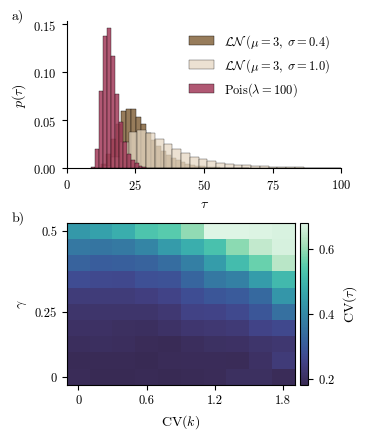

In [ ]:
# Style settings
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False

plt.style.use('tableau-colorblind10')
plt.rcParams["figure.autolayout"] = True
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 10
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9

plt.rcParams.update({
    "font.size": 10,
    "font.family": "serif",
    "font.serif": "cmr10",
    "mathtext.fontset": "cm",
    "axes.formatter.use_mathtext": True
})

# Tick parameters
TOP_YTICKS = None

BOT_XTICKS_CV = [0.0, 0.6, 1.2, 1.8]
BOT_YTICKS_GAMMA = [0.0, 0.25, 0.5]

CBAR_VMAX = 0.68
CBAR_TICKS = [0.2, 0.4, 0.6]

# Interpolation resolution
NX_FINE = 10
NY_FINE = 10

# Utility functions
def coefficient_of_variation(x):
    x = np.asarray(x, dtype=float)
    m = np.nanmean(x)
    s = np.nanstd(x)
    return s / m if np.isfinite(m) and m != 0 else np.nan

def load_hwhm_from_npz(folder, dist, gamma, sig_ln=None):
    files = glob.glob(os.path.join(folder, "*.npz"))
    out = []
    for f in files:
        d = np.load(f, allow_pickle=True)
        if "distribution" in d and str(d["distribution"]) != dist:
            continue
        if "gamma" in d and not np.isclose(float(d["gamma"]), gamma):
            continue
        if sig_ln is not None and "sig_ln" in d and not np.isclose(float(d["sig_ln"]), sig_ln):
            continue
        h = np.asarray(d["HWHM"]).ravel()
        h = h[np.isfinite(h)]
        if h.size:
            out.append(h)
    if len(out) == 0:
        raise RuntimeError(f"No file found for dist={dist}, gamma={gamma}, sig_ln={sig_ln}")
    return np.concatenate(out)

# Figure size
W_CM = 9
H_CM = 12
fig = plt.figure(figsize=(W_CM/2.54, H_CM/2.54))
gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[1.0, 1.1], hspace=0.35)
ax_top = fig.add_subplot(gs[0, 0])
ax_bot = fig.add_subplot(gs[1, 0])

# Panel labels
ax_top.text(-0.2, 1.08, "a)", transform=ax_top.transAxes, ha="left", va="top")
ax_bot.text(-0.24, 1.07, "b)", transform=ax_bot.transAxes, ha="left", va="top")

# Top panel histograms
poiss_dir = os.path.join(OUT_PATH, "sim_timescale_poiss")
logn_dir_hist = os.path.join(OUT_PATH, "sim_timescale")

gamma_poiss = 0.4
gamma_logn  = 0.4
sigma_pair  = (0.4, 1.0)

h_poiss = load_hwhm_from_npz(poiss_dir,      dist="poisson",    gamma=gamma_poiss)
h_l1    = load_hwhm_from_npz(logn_dir_hist,  dist="log_normal", gamma=gamma_logn, sig_ln=sigma_pair[0])
h_l2    = load_hwhm_from_npz(logn_dir_hist,  dist="log_normal", gamma=gamma_logn, sig_ln=sigma_pair[1])

# Colors for histograms
col_sig1 = "#927552"   # khaki
col_sig2 = "#E6D8C3"   # light sand
col_pois = "#A23B5A"   # wine
edge_col = "black"
lw = 0.3

bins_l1 = 100
bins_l2 = 150
bins_p  = 40

ax_top.hist(
    h_l1, bins=bins_l1, density=True, alpha=0.95,
    color=col_sig1, edgecolor=edge_col, linewidth=lw,
    label=rf'$\mathcal{{LN}}\;(\mu=3,\;\sigma={sigma_pair[0]})$'
)

ax_top.hist(
    h_l2, bins=bins_l2, density=True, alpha=0.75,
    color=col_sig2, edgecolor=edge_col, linewidth=lw,
    label=rf'$\mathcal{{LN}}\;(\mu=3,\;\sigma={sigma_pair[1]})$'
)

ax_top.hist(
    h_poiss, bins=bins_p, density=True, alpha=0.85,
    color=col_pois, edgecolor=edge_col, linewidth=lw,
    label=r'$\mathrm{Pois}(\lambda=100)$'
)

ax_top.set_xlim(0, 100)
ax_top.set_xlabel(r'$\tau$')
ax_top.set_ylabel(r'$p(\tau)$')
ax_top.legend(frameon=False, fontsize=9)
ax_top.set_xticks([0, 25, 50, 75, 100])

if TOP_YTICKS is not None:
    ax_top.set_yticks(TOP_YTICKS)
    ax_top.set_yticklabels([f"{t:g}" for t in TOP_YTICKS])

# Bottom panel heatmap with smooth interpolation
logn_dir_cv = os.path.join(OUT_PATH, "sim_timescale_cv")
files = [f for f in os.listdir(logn_dir_cv) if f.endswith(".npz")]

rows = []
for file in files:
    path = os.path.join(logn_dir_cv, file)
    data = np.load(path, allow_pickle=True)

    HWHM   = np.asarray(data["HWHM"], dtype=float)
    sig_ln = float(data["sig_ln"])
    gamma  = float(data["gamma"])

    h = HWHM[np.isfinite(HWHM)]

    rows.append({
        "gamma": gamma,
        "sig_ln": sig_ln,
        "hwhm_cv": coefficient_of_variation(h),
    })

df_runs = pd.DataFrame(rows)

df_group = (
    df_runs.groupby(["gamma", "sig_ln"], as_index=False)
    .agg(hwhm_cv_mean=("hwhm_cv", "mean"))
)

df_group["cv"] = np.sqrt(np.exp(df_group["sig_ln"]**2) - 1)

pivot = df_group.pivot(index="gamma", columns="cv", values="hwhm_cv_mean")

gamma_vals = pivot.index.values.astype(float)
cv_vals    = pivot.columns.values.astype(float)

# Sort axes
g_order = np.argsort(gamma_vals)
c_order = np.argsort(cv_vals)
gamma_vals = gamma_vals[g_order]
cv_vals = cv_vals[c_order]
Z = pivot.values[np.ix_(g_order, c_order)]

# Known points for interpolation
X0, Y0 = np.meshgrid(cv_vals, gamma_vals)
mask = np.isfinite(Z)
points = np.column_stack([X0[mask], Y0[mask]])
values = Z[mask]

# Fine grid for a smoother visualization
cv_fine = np.linspace(cv_vals.min(), cv_vals.max(), NX_FINE)
gamma_fine = np.linspace(gamma_vals.min(), gamma_vals.max(), NY_FINE)
Xf, Yf = np.meshgrid(cv_fine, gamma_fine)

Z_fine = griddata(points, values, (Xf, Yf), method="linear")
if np.isnan(Z_fine).any():
    Z_near = griddata(points, values, (Xf, Yf), method="nearest")
    Z_fine = np.where(np.isnan(Z_fine), Z_near, Z_fine)

# Build edges from centers for pcolormesh
cv_edges = np.empty(len(cv_fine) + 1)
cv_edges[1:-1] = 0.5 * (cv_fine[1:] + cv_fine[:-1])
cv_edges[0]    = cv_fine[0] - 0.5 * (cv_fine[1] - cv_fine[0])
cv_edges[-1]   = cv_fine[-1] + 0.5 * (cv_fine[-1] - cv_fine[-2])

gamma_edges = np.empty(len(gamma_fine) + 1)
gamma_edges[1:-1] = 0.5 * (gamma_fine[1:] + gamma_fine[:-1])
gamma_edges[0]    = gamma_fine[0] - 0.5 * (gamma_fine[1] - gamma_fine[0])
gamma_edges[-1]   = gamma_fine[-1] + 0.5 * (gamma_fine[-1] - gamma_fine[-2])

# Select cmap
base = cm.get_cmap("mako")

# remove darkest 25 percent
light_mako = LinearSegmentedColormap.from_list(
    "light_mako",
    base(np.linspace(0.20, 1.0, 256))
)

# Heatmap plot
pm = ax_bot.pcolormesh(
    cv_edges, gamma_edges, Z_fine,
    shading="flat",
    cmap=light_mako,
    vmin=float(np.nanmin(Z_fine)),
    vmax=CBAR_VMAX
)

ax_bot.spines["top"].set_visible(True)
ax_bot.spines["right"].set_visible(True)

# Snap requested ticks to nearest cell centers
def snap_to_centers(targets, centers):
    centers = np.asarray(centers, dtype=float)
    pos = []
    lab = []
    for t in targets:
        idx = int(np.argmin(np.abs(centers - t)))
        pos.append(float(centers[idx]))
        lab.append(t)
    return pos, lab

x_pos, x_lab = snap_to_centers(BOT_XTICKS_CV, cv_fine)
y_pos, y_lab = snap_to_centers(BOT_YTICKS_GAMMA, gamma_fine)

ax_bot.set_xticks(x_pos)
ax_bot.set_xticklabels([f"{t:.2g}" for t in x_lab])

ax_bot.set_yticks(y_pos)
ax_bot.set_yticklabels([f"{t:.3g}" for t in y_lab])

ax_bot.set_xlabel(r'$\mathrm{CV}(k)$')
ax_bot.set_ylabel(r'$\gamma$')

# Single colorbar
cbar = fig.colorbar(pm, ax=ax_bot, pad=0.02)
cbar.set_ticks([t for t in CBAR_TICKS if float(np.nanmin(Z_fine)) <= t <= CBAR_VMAX])
cbar.set_label(r'$\mathrm{CV}(\tau)$')

plt.savefig("/home/taffarello/codes/rnn/figures/Heterog_RNN/Panel_Timescales.png", dpi=400, bbox_inches="tight")
plt.show()